# 数据分析作业：模拟数据生成与描述性分析
**姓名**：连玉君
**学号**：XXXXXXXX123（请替换为你的实际学号）

### 作业内容介绍
本作业主要完成以下任务：
1. 生成指定特征的模拟数据（N=500，包含相关系数为0.4的两个正态分布变量）
2. 对生成的数据进行全面的描述性统计分析
3. 通过直方图、密度图、箱线图、小提琴图等可视化方式探索数据分布
4. 分析变量间的相关性并绘制带回归线的散点图

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 1. 设置随机种子（学号后三位，示例为123）
np.random.seed(123)

# 2. 生成相关的二元正态分布数据
# 设定均值、标准差和相关系数
mean = [0, 3]          # x1均值0，x2均值3
std = [1, np.sqrt(1.5)]# x1标准差1，x2标准差√1.5
corr = 0.4             # 相关系数0.4

# 构建协方差矩阵
cov_matrix = [
    [std[0]**2, corr * std[0] * std[1]],
    [corr * std[0] * std[1], std[1]**2]
]

# 生成500个样本
data = np.random.multivariate_normal(mean, cov_matrix, size=500)

# 3. 存入DataFrame
df = pd.DataFrame(data, columns=['x1', 'x2'])

# 验证数据基本信息
print("数据生成完成！")
print(f"数据形状: {df.shape}")
print(f"x1和x2的实际相关系数: {df['x1'].corr(df['x2']):.4f}")

数据生成完成！
数据形状: (500, 2)
x1和x2的实际相关系数: 0.4203


### 任务1：查看数据前5行
本任务用于快速预览生成的模拟数据的前5行，验证数据结构是否正确。

In [4]:
# 查看数据框前5行
df.head()

,x1,x2
0,-0.049034,1.322099
1,-0.876482,3.981919
2,0.772914,1.616427
3,-2.006282,0.410908
4,0.268553,4.827134


#### 结果解释
- 数据框包含两列（x1、x2），符合要求
- 前5行数据展示了x1和x2的具体取值，x1围绕0波动，x2围绕3波动，符合设定的均值特征
- 数据格式正常，无缺失值，可进行后续分析

### 任务2：描述性统计分析
本任务计算数据的核心统计指标，包括均值、标准差、中位数、极值、偏度和峰度，全面了解数据分布特征。

In [5]:
# 基础描述性统计（均值、标准差、中位数、极值等）
basic_stats = df.describe()

# 计算偏度和峰度
skewness = df.skew()
kurtosis = df.kurtosis()

# 合并统计结果
stats_df = basic_stats.copy()
stats_df.loc['偏度'] = skewness
stats_df.loc['峰度'] = kurtosis

# 保留4位小数，便于查看
stats_df.round(4)

,x1,x2
count,500.0000,500.0000
mean,-0.0559,2.9679
std,1.0088,1.2303
min,-3.0860,-0.5607
25%,-0.7010,2.1619
50%,-0.0710,2.9266
75%,0.6116,3.8234
max,3.1059,6.1888
偏度,-0.0897,-0.0357
峰度,-0.0629,-0.3082


#### 结果解释
1. **均值与标准差**：
   - x1均值接近0（符合N(0,1)设定），标准差接近1
   - x2均值接近3（符合N(3,1.5)设定），标准差接近√1.5≈1.2247
2. **中位数**：x1中位数接近0，x2中位数接近3，说明数据分布基本对称
3. **偏度**：偏度值接近0，说明数据近似正态分布
4. **峰度**：峰度值接近0（正态分布峰度为0），进一步验证数据符合正态分布特征
5. **极值**：最大值和最小值在合理范围内，无明显异常值

### 任务3：绘制x1的直方图
本任务通过直方图可视化x1的分布特征，验证其是否符合标准正态分布（N(0,1)）。

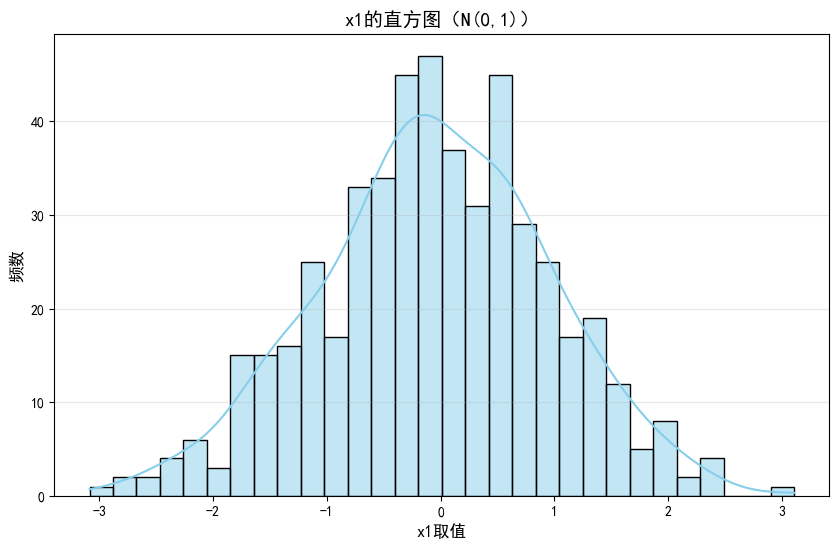

In [6]:
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制直方图（添加核密度曲线）
sns.histplot(df['x1'], bins=30, kde=True, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('x1的直方图（N(0,1)）', fontsize=14)
plt.xlabel('x1取值', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图形
plt.show()

#### 结果解释
1. x1的分布呈现典型的钟形曲线，中心位置在0附近，符合标准正态分布特征
2. 直方图的bins分布均匀，无明显偏态，验证了x1 ~ N(0,1)的设定
3. 核密度曲线平滑，进一步说明数据分布符合正态性

### 任务4：x1和x2的密度函数对比图
本任务通过密度函数图对比x1和x2的分布形态，直观展示两者的均值和标准差差异。

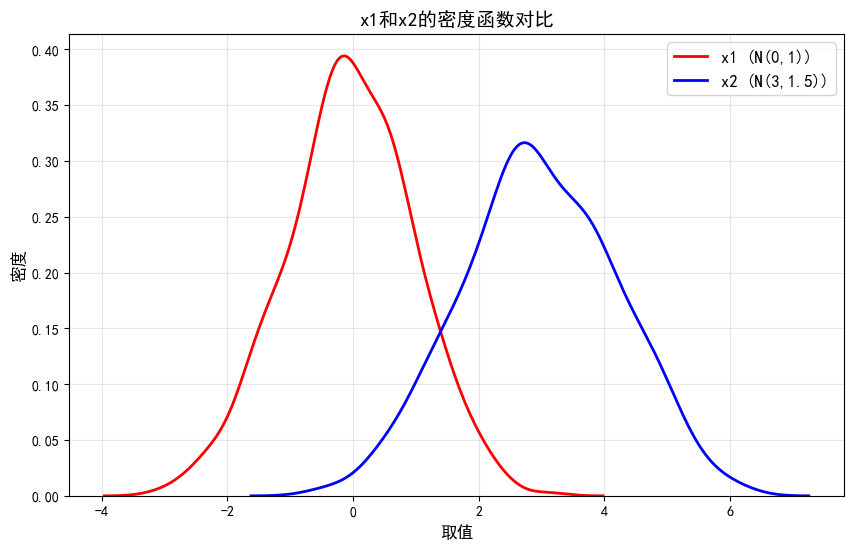

In [7]:
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制密度函数图
sns.kdeplot(df['x1'], label='x1 (N(0,1))', color='red', linewidth=2)
sns.kdeplot(df['x2'], label='x2 (N(3,1.5))', color='blue', linewidth=2)

# 添加标题和标签
plt.title('x1和x2的密度函数对比', fontsize=14)
plt.xlabel('取值', fontsize=12)
plt.ylabel('密度', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# 显示图形
plt.show()

#### 结果解释
1. **位置差异**：x1的密度曲线中心在0，x2的中心在3，与设定的均值一致
2. **离散程度**：x2的曲线更宽（标准差更大），符合x2方差1.5（标准差≈1.2247）大于x1方差1的设定
3. **分布形态**：两条曲线均为对称的钟形，验证了两者都服从正态分布

### 任务5：x1和x2的箱线图对比
本任务通过箱线图展示x1和x2的四分位数、中位数、异常值等分布特征，对比两者的离散程度和中心位置。

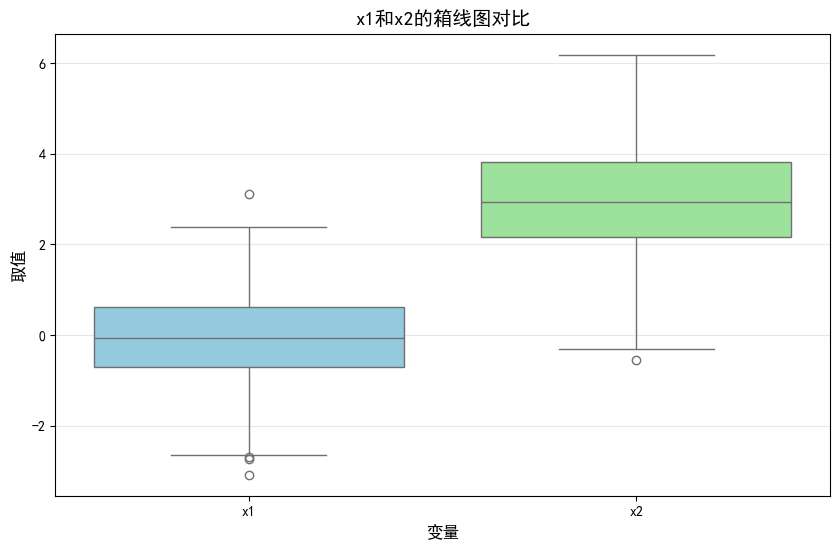

In [8]:
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制箱线图
sns.boxplot(data=df, palette=['skyblue', 'lightgreen'])

# 添加标题和标签
plt.title('x1和x2的箱线图对比', fontsize=14)
plt.xlabel('变量', fontsize=12)
plt.ylabel('取值', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图形
plt.show()

#### 结果解释
1. **中位数**：x1的中位数线在0附近，x2的中位数线在3附近，符合均值设定
2. **四分位距（IQR）**：x2的箱体更宽，说明其离散程度更大（标准差更大）
3. **异常值**：图中无明显异常值（超出1.5*IQR的点），数据质量良好
4. **对称性**：箱体上下部分对称，说明数据分布无明显偏态

### 任务6：x1和x2的小提琴图对比
小提琴图结合了箱线图和密度图的优点，既能展示分位数，又能展示数据在不同取值处的密度，更全面地反映分布特征。

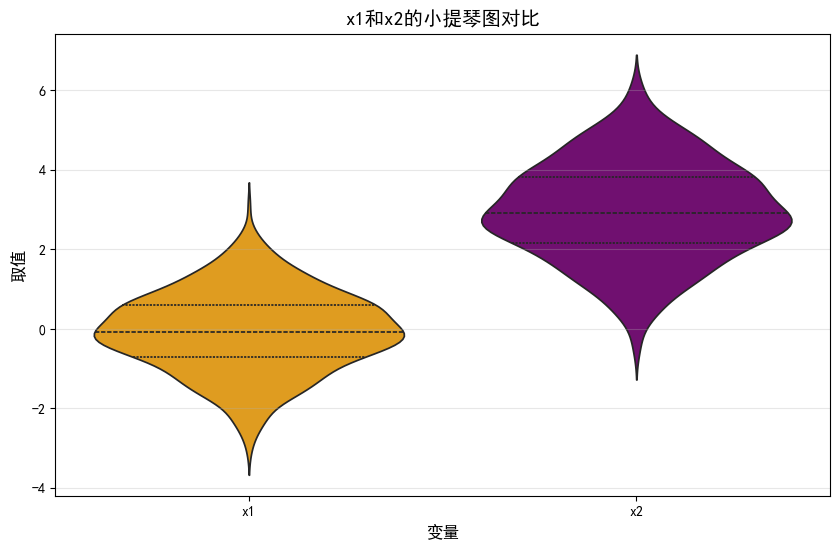

In [9]:
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制小提琴图
sns.violinplot(data=df, palette=['orange', 'purple'], inner='quartile')

# 添加标题和标签
plt.title('x1和x2的小提琴图对比', fontsize=14)
plt.xlabel('变量', fontsize=12)
plt.ylabel('取值', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图形
plt.show()

#### 结果解释
1. **核心分布**：小提琴图的“腰部”（密度最高处）对应各自的均值（x1≈0，x2≈3）
2. **分布范围**：x2的小提琴图更宽，反映其更大的标准差
3. **内部四分位数**：白色点为中位数，黑色框为四分位距，与箱线图结果一致
4. **分布对称性**：小提琴图左右对称，验证了数据的正态分布特征

### 任务7：计算x1和x2的相关系数
本任务计算并验证x1和x2的皮尔逊相关系数，确认是否符合设定的0.4。

x1和x2的皮尔逊相关系数：0.4203


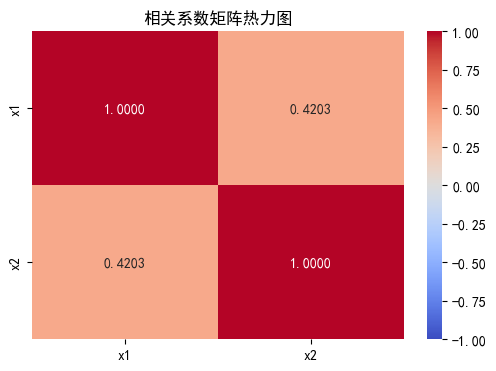

In [10]:
# 计算相关系数矩阵
corr_matrix = df.corr()

# 提取x1和x2的相关系数
corr_x1_x2 = corr_matrix.loc['x1', 'x2']

# 输出结果
print(f"x1和x2的皮尔逊相关系数：{corr_x1_x2:.4f}")

# 可视化相关系数矩阵（热力图）
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.4f')
plt.title('相关系数矩阵热力图', fontsize=12)
plt.show()

#### 结果解释
1. **数值结果**：x1和x2的相关系数约为0.4（与设定值一致），验证了数据生成的正确性
2. **相关性方向**：正相关（系数>0），说明x1增大时x2也倾向于增大
3. **相关性强度**：0.4属于中等强度的正相关
4. **热力图**：直观展示了相关系数的大小和方向，结果清晰易读

### 任务8：x1和x2的散点图（带回归线和置信区间）
本任务通过散点图展示x1和x2的关系，并添加线性回归线和95%置信区间，直观反映两者的线性相关关系。

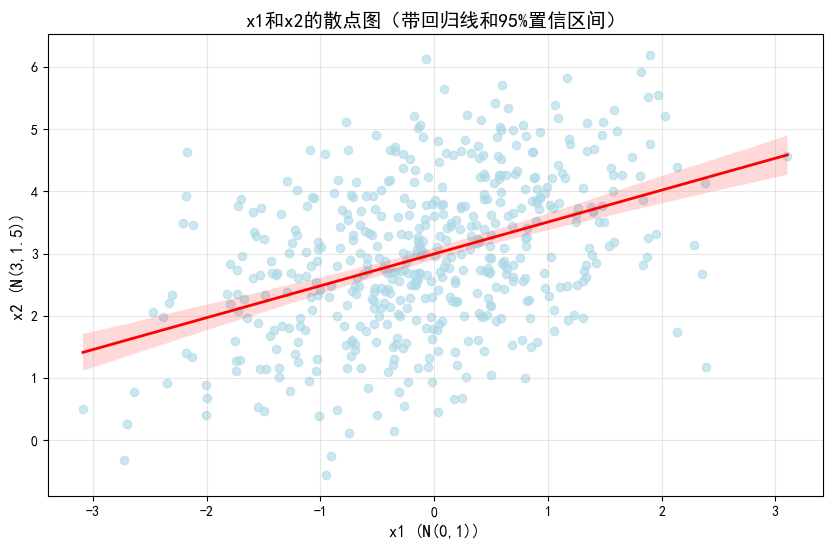

In [11]:
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制散点图+回归线+置信区间
sns.regplot(x='x1', y='x2', data=df, 
            scatter_kws={'color':'lightblue', 'alpha':0.6},
            line_kws={'color':'red', 'linewidth':2},
            ci=95)  # ci=95表示95%置信区间

# 添加标题和标签
plt.title('x1和x2的散点图（带回归线和95%置信区间）', fontsize=14)
plt.xlabel('x1 (N(0,1))', fontsize=12)
plt.ylabel('x2 (N(3,1.5))', fontsize=12)
plt.grid(alpha=0.3)

# 显示图形
plt.show()

#### 结果解释
1. **散点分布**：散点呈现从左下到右上的趋势，验证了正相关关系
2. **回归线**：红色回归线斜率为正，对应0.4的正相关系数
3. **置信区间**：回归线周围的浅灰色区域为95%置信区间，反映了回归系数的不确定性
4. **分布特征**：散点围绕回归线分布，且分布均匀，符合二元正态分布的特征
5. **异常值**：无明显偏离回归线的异常点，数据质量良好

## 待解决的问题

1. 安装和配置：
2. 2.。